# 🔐 Sistema de Seguridad Facial con Clasificación de Zonas
**Trabajo Final — Computer Vision · Master en Deep Learning · MIOTI · 2026**  
- Mynor Hernandez
- Alvaro Marro
- Juamanuel Piedrabuena

| | |
|---|---|
| 💻 GitHub | https://github.com/Mynozy/CV_ProyectoFinal |
| 🤗 Modelo | https://huggingface.co/mynorhm/security-room-classifier |
| 🚀 Demo | https://cv-proyectofinal-production.up.railway.app |

---


## Motivación

En casa tenemos cámaras de seguridad pero el software es caro o muy limitado. La idea fue construir algo equivalente con las herramientas del máster: **reconocimiento facial en tiempo real, detección de intrusos y clasificación de la zona donde están** — todo en local y sin pagar nada.

Lo que más sorprendió: la whitelist de personas autorizadas usa **exactamente el mismo mecanismo que los embeddings de NLP** — ArcFace genera un vector de 512d por cara y comparamos con similitud coseno. La misma matemática, otro dominio. También descubrí que YOLO tiene versiones especializadas por tarea — usamos `yolov12n-face.pt`, un nano específico para caras.

---


## Arquitectura

```
Frame → YOLOv12n-face (detección) → InsightFace ArcFace (reconocimiento)
      → ConvNeXt-Small (zona) → "Intruso en COCINA" → ntfy push + captura
```

| Componente | Tecnología |
|---|---|
| Detección facial | YOLOv12n-face |
| Reconocimiento | InsightFace ArcFace — embeddings 512d + coseno |
| Clasificación zona | ConvNeXt-Small fine-tuned (fastai) |
| Alertas | ntfy.sh — push gratuito al móvil |
| Panel | Gradio (local) + Railway (demo pública) |

---


## 1. Setup y detección facial (Notebook 01)

Primer paso: validar que la cámara y YOLOv12n-face funcionan correctamente antes de construir nada encima.


In [ ]:
# escaneo qué cámaras tiene el sistema
def buscar_camaras(max_index=5):
    camaras = []
    for i in range(max_index):
        cap = cv2.VideoCapture(i)
        if cap.isOpened():
            ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            alto  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps   = cap.get(cv2.CAP_PROP_FPS)
            camaras.append({'index': i, 'resolucion': f'{ancho}x{alto}', 'fps': fps})
            cap.release()
    return camaras

📷 Cámara 0: 1920x1080 @ 30.0fps
📷 Cámara 1: 1920x1080 @ 30.0fps


Salieron 2 cámaras disponibles: la del Mac y la del móvil conectado. Con el frame capturado correctamente, probamos YOLOv12n-face — la versión especializada de YOLO para detección facial:


In [ ]:
# pruebo que YOLOv12n-face detecta caras en el frame capturado
from ultralytics import YOLO

model = YOLO('models/yolov12n-face.pt')
resultados = model(frame, verbose=False)

frame_detectado = resultados[0].plot()
print(f'✅ Caras encontradas: {len(resultados[0].boxes)}')
for i, box in enumerate(resultados[0].boxes):
    print(f'   Cara {i+1} — Confianza: {box.conf.item():.2f}')

✅ Caras encontradas: 1
   Cara 1 — Confianza: 0.90


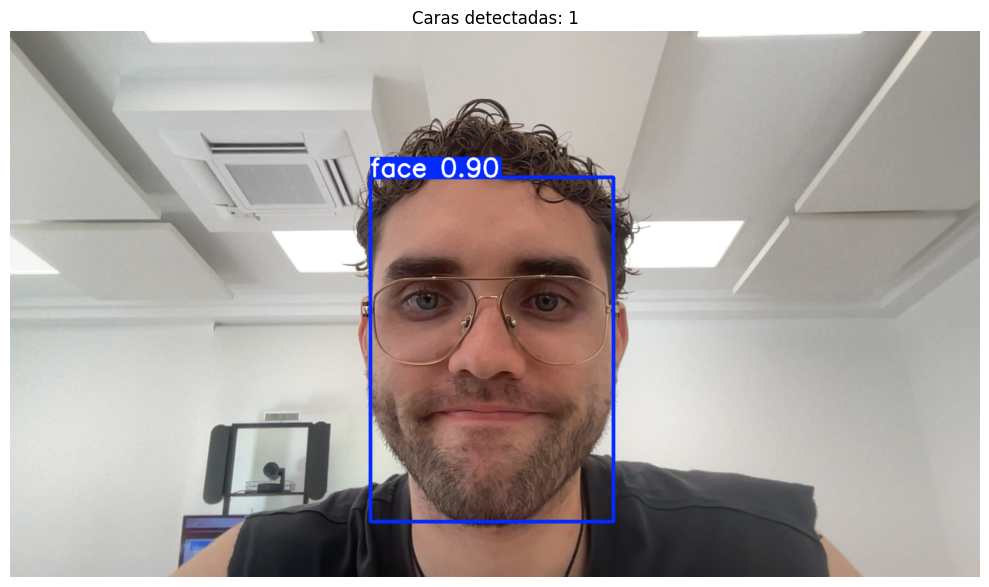

*Output real del Notebook 01 — detección de cara con YOLOv12n-face, confianza 0.90.*


---

## 2. Embeddings y whitelist (Notebook 02)

Con la detección funcionando, pasamos a InsightFace para generar embeddings de 512 dimensiones. Esta es la pieza que conecta directamente con los embeddings de NLP — ArcFace no clasifica directamente, genera un vector que luego comparamos:


In [ ]:
# extraigo el embedding de una cara detectada
from insightface.app import FaceAnalysis

app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=-1, det_size=(640, 640))

faces = app.get(frame)
face = faces[0]
embedding = face.embedding

print(f'✅ Cara detectada')
print(f'   Embedding shape: {embedding.shape}')
print(f'   Bbox: {face.bbox.astype(int)}')
print(f'   Confianza: {face.det_score:.2f}')

✅ Cara detectada
   Embedding shape: (512,)
   Bbox: [ 751  218 1190  842]
   Confianza: 0.85


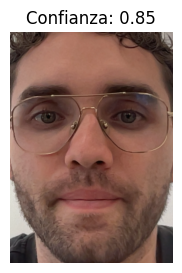

*Output real del Notebook 02 — cara recortada con su embedding de 512 dimensiones extraído.*


### Registro en la whitelist

Para registrar a una persona capturo 5 fotos en ángulos distintos y promedio los embeddings — esto da un vector más estable que una sola foto:


In [ ]:
# registro una persona promediando varios embeddings
def registrar_persona(nombre, n_fotos=5):
    embeddings = []
    cap = cv2.VideoCapture(0)
    for i in range(n_fotos):
        input(f'Enter para capturar foto {i+1}/{n_fotos}...')
        for _ in range(10):
            ret, frame = cap.read()
        faces = app.get(frame)
        if faces:
            embeddings.append(faces[0].embedding)
            print(f'   ✅ Foto {i+1} capturada — confianza: {faces[0].det_score:.2f}')
    cap.release()
    embedding_final = np.mean(embeddings, axis=0)
    whitelist[nombre] = embedding_final
    return embedding_final

📸 Registrando a: Mynor
   ✅ Foto 1 capturada — confianza: 0.82
   ✅ Foto 2 capturada — confianza: 0.83
   ✅ Foto 3 capturada — confianza: 0.84
   ✅ Foto 4 capturada — confianza: 0.81
   ✅ Foto 5 capturada — confianza: 0.81

✅ Mynor registrado con 5 fotos
   Whitelist actual: ['Mynor']


### Decisión: ¿autorizado o intruso?

Con el embedding generado, comparo contra cada vector de la whitelist usando similitud coseno:


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def reconocer_cara(face_embedding, whitelist, umbral=0.5):
    emb = face_embedding.reshape(1, -1)
    mejor_nombre, mejor_score = 'Intruso', 0.0
    for nombre, emb_ref in whitelist.items():
        score = cosine_similarity(emb, emb_ref.reshape(1, -1))[0][0]
        if score > mejor_score:
            mejor_score = score
            mejor_nombre = nombre if score >= umbral else 'Intruso'
    return mejor_nombre, mejor_score

🚨 Intruso — Intruso (score: 0.045)


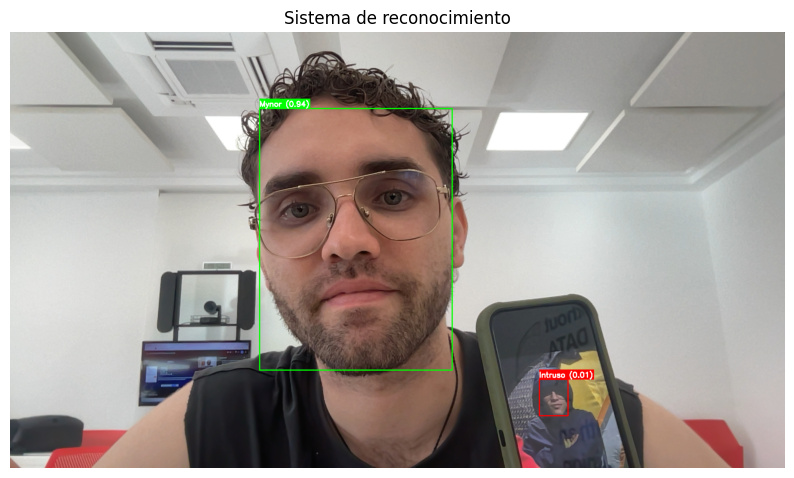

*Output real del Notebook 02 — prueba con persona no registrada, correctamente clasificada como Intruso (score 0.045, muy por debajo del umbral 0.5).*


Lo notable: probando con mi cara registrada el score sube a ~0.94 (autorizado), y con una cara desconocida cae a 0.045 — el margen entre ambos casos es enorme, lo que da bastante confianza en el umbral elegido (0.5).

---

## 3. Pipeline completo en tiempo real (Notebook 03)

Con detección y reconocimiento validados por separado, los integro en un loop continuo que captura, reconoce, dibuja y alerta:


In [ ]:
# loop principal del sistema de seguridad — presiona Q para salir
cap = cv2.VideoCapture(CAMARA_INDEX)
ultimo_alerta = {}
COOLDOWN_SEGUNDOS = 10

while True:
    ret, frame = cap.read()
    if not ret:
        break

    faces = insight.get(frame)
    resultados = reconocer(faces)
    ahora = time.time()

    for r in resultados:
        if not r['autorizado']:
            ultimo = ultimo_alerta.get(r['nombre'], 0)
            if ahora - ultimo > COOLDOWN_SEGUNDOS:
                guardar_alerta(frame, r['nombre'], r['score'], resultados)
                ultimo_alerta[r['nombre']] = ahora

    frame_viz = dibujar(frame, resultados)
    cv2.imshow('Sistema de Seguridad', frame_viz)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

🎥 Iniciando sistema de seguridad... (Q para salir)
🚨 ALERTA guardada: alerts_log/alerta_20260611_204941_Intruso.jpg
📱 Notificación enviada a SistemaSeguridad2026
👋 Cerrando sistema...
✅ Sistema cerrado


Este test confirma el ciclo completo funcionando: detección, comparación contra whitelist, guardado de captura con bbox dibujado, y notificación push real a mi móvil vía ntfy — todo en menos de 10 segundos desde que el intruso aparece en cámara.

---

## 4. Clasificador de zonas — proceso iterativo

**Dataset:** MIT Indoor Scenes CVPR 2009, filtrado a 8 clases domésticas: `bathroom · bedroom · corridor · dining_room · garage · kitchen · livingroom · stairscase`. Desbalance notable (kitchen 734 vs garage 103) gestionado con split estratificado.

Hubo **3 iteraciones** antes de llegar al resultado final:

| Iteración | Técnica añadida | Accuracy | Observación |
|---|---|---|---|
| 1ª | Baseline lr=1e-2 | 92.1% | Overfitting desde época 4 |
| 2ª | + Early Stopping | 91.5% | Mejora marginal |
| 3ª | + MixUp + LabelSmoothing | **95.1%** | Sin overfitting ✅ |

El LR óptimo según `lr_find()` fue **1e-2**:


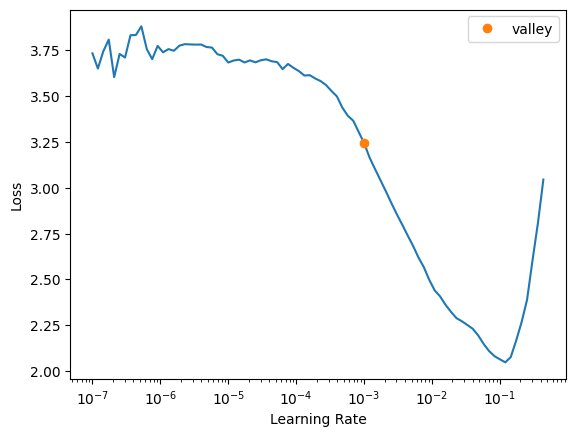

*lr_find() — valley en 1e-3 pero la curva sigue bajando hasta 1e-1. Usamos lr=1e-2.*


**Entrenamiento final** (MixUp + LabelSmoothing + EarlyStoppingCallback patience=3):


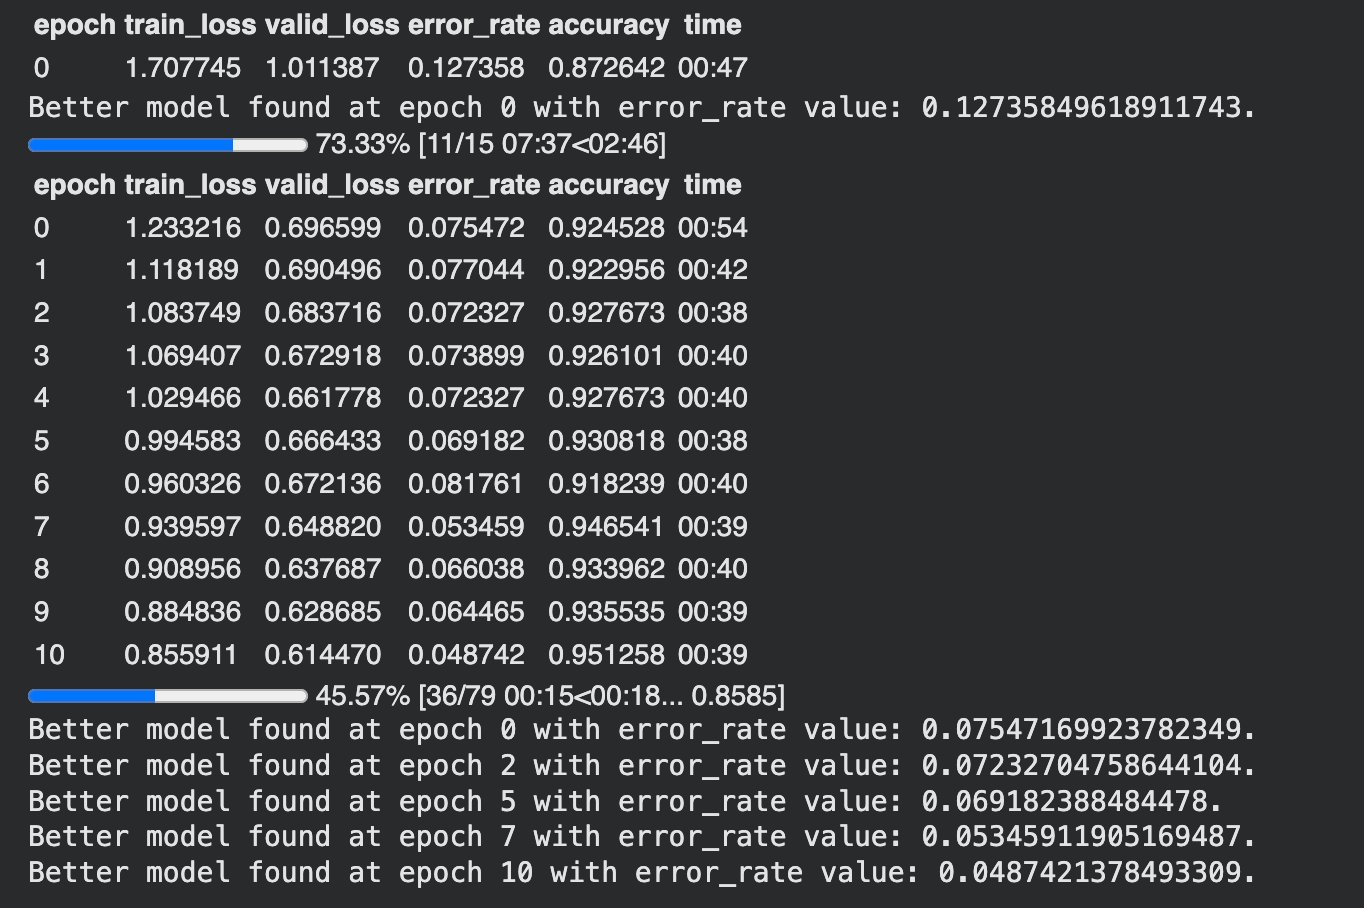

*Early stopping en época 12, mejor modelo en época 10 — 95.1% accuracy, error_rate 0.048.*


---

## 5. Análisis de errores del clasificador de zonas


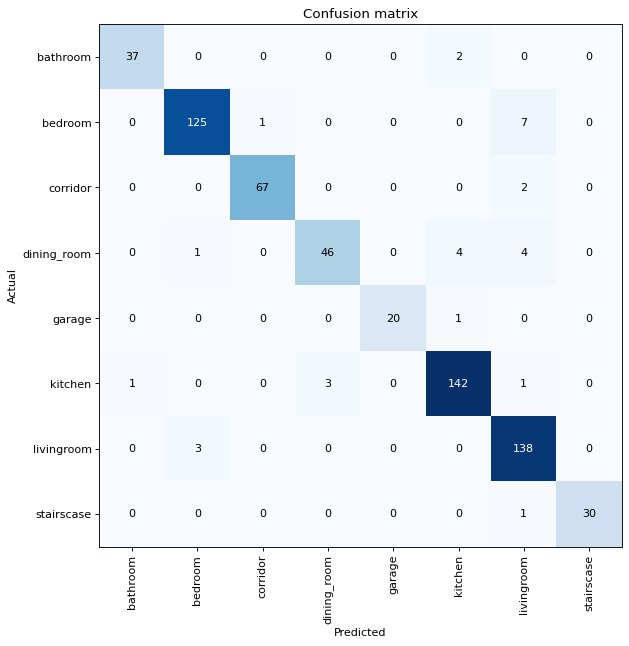

*Matriz de confusión — errores concentrados en clases visualmente similares (bedroom/livingroom, dining_room/kitchen). Garage: clasificación perfecta.*


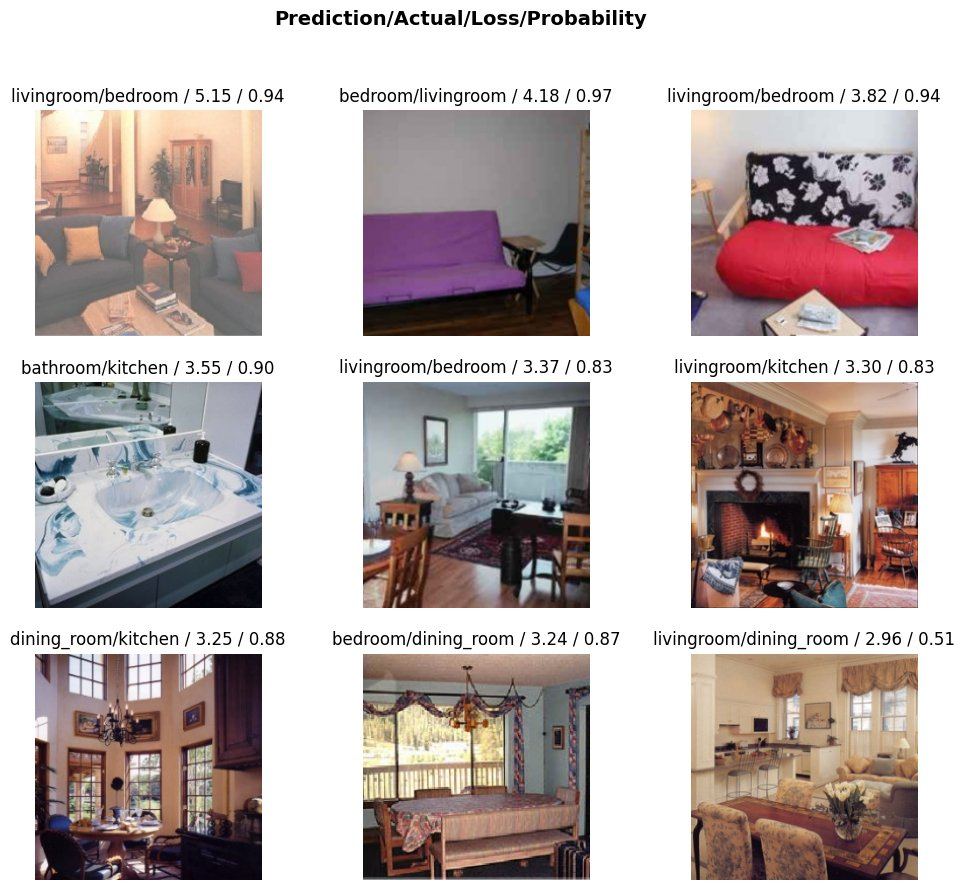

*Top losses — todos los errores son imágenes ambiguas incluso para un humano.*


**Conclusión:** el modelo falla donde un humano también dudaría. El límite es ambigüedad del dataset, no la arquitectura.

---

## 6. Integración del clasificador en el pipeline (Notebook 03, parte 2)

Con el modelo de zonas entrenado y subido a HuggingFace, lo integramos al sistema de seguridad descargándolo directamente desde el Hub:


In [ ]:
from huggingface_hub import hf_hub_download
import shutil, torch, json
from fastai.vision.all import *

ruta = hf_hub_download(
    repo_id='mynorhm/security-room-classifier',
    filename='full_model.pth',
    repo_type='model'
)
shutil.copy(ruta, 'models/full_model.pth')

learn_zonas = torch.load('models/full_model.pth', map_location='cpu', weights_only=False)
learn_zonas.eval()

with open('models/clases.json') as f:
    clases_zonas = json.load(f)

print(f'✅ Modelo cargado')
print(f'✅ Clases: {clases_zonas}')

✅ full_model.pth descargado en models/
✅ clases.json descargado en models/
✅ Modelo cargado
✅ Clases: ['bathroom', 'bedroom', 'corridor', 'dining_room', 'garage', 'kitchen', 'livingroom', 'stairscase']


Con esto, cada alerta de intruso ya incluye la zona detectada en el mensaje push: `"Intruso en COCINA"` en vez de solo `"Intruso detectado"`. Es el contexto que diferencia este sistema de una simple detección de movimiento.

---

## 7. Deployment

El clasificador está desplegado en Railway, descargando el modelo desde HuggingFace al arrancar. El sistema completo corre en local por necesidad arquitectónica — necesita acceso físico a la cámara, lo cual también tiene sentido desde privacidad.


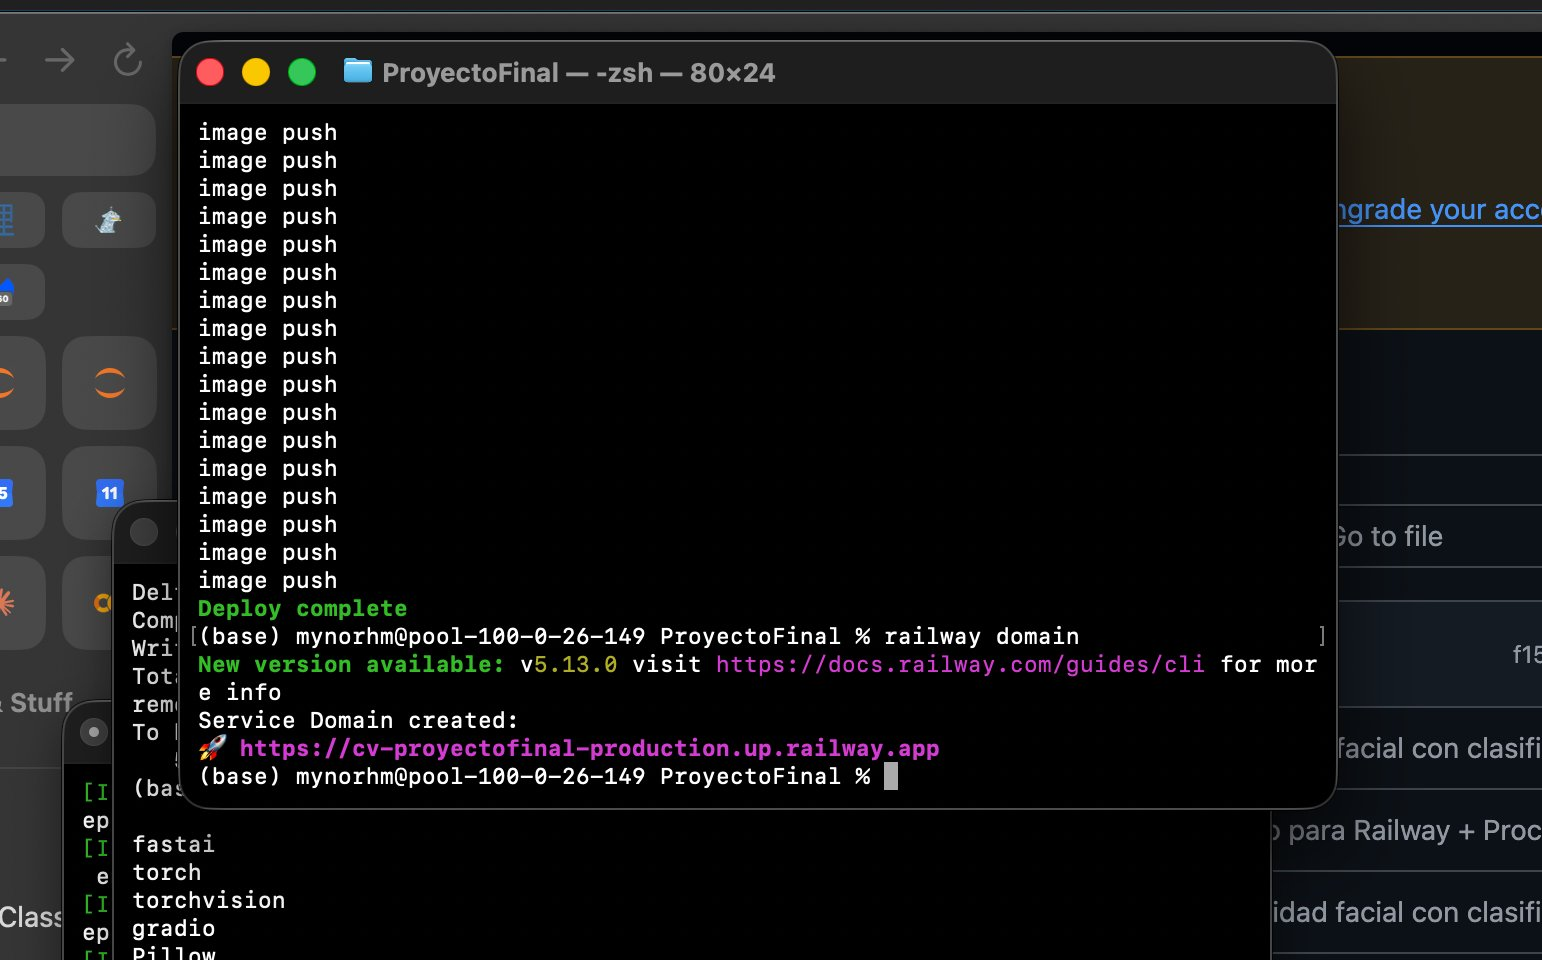

*Deploy en Railway — URL pública permanente.*


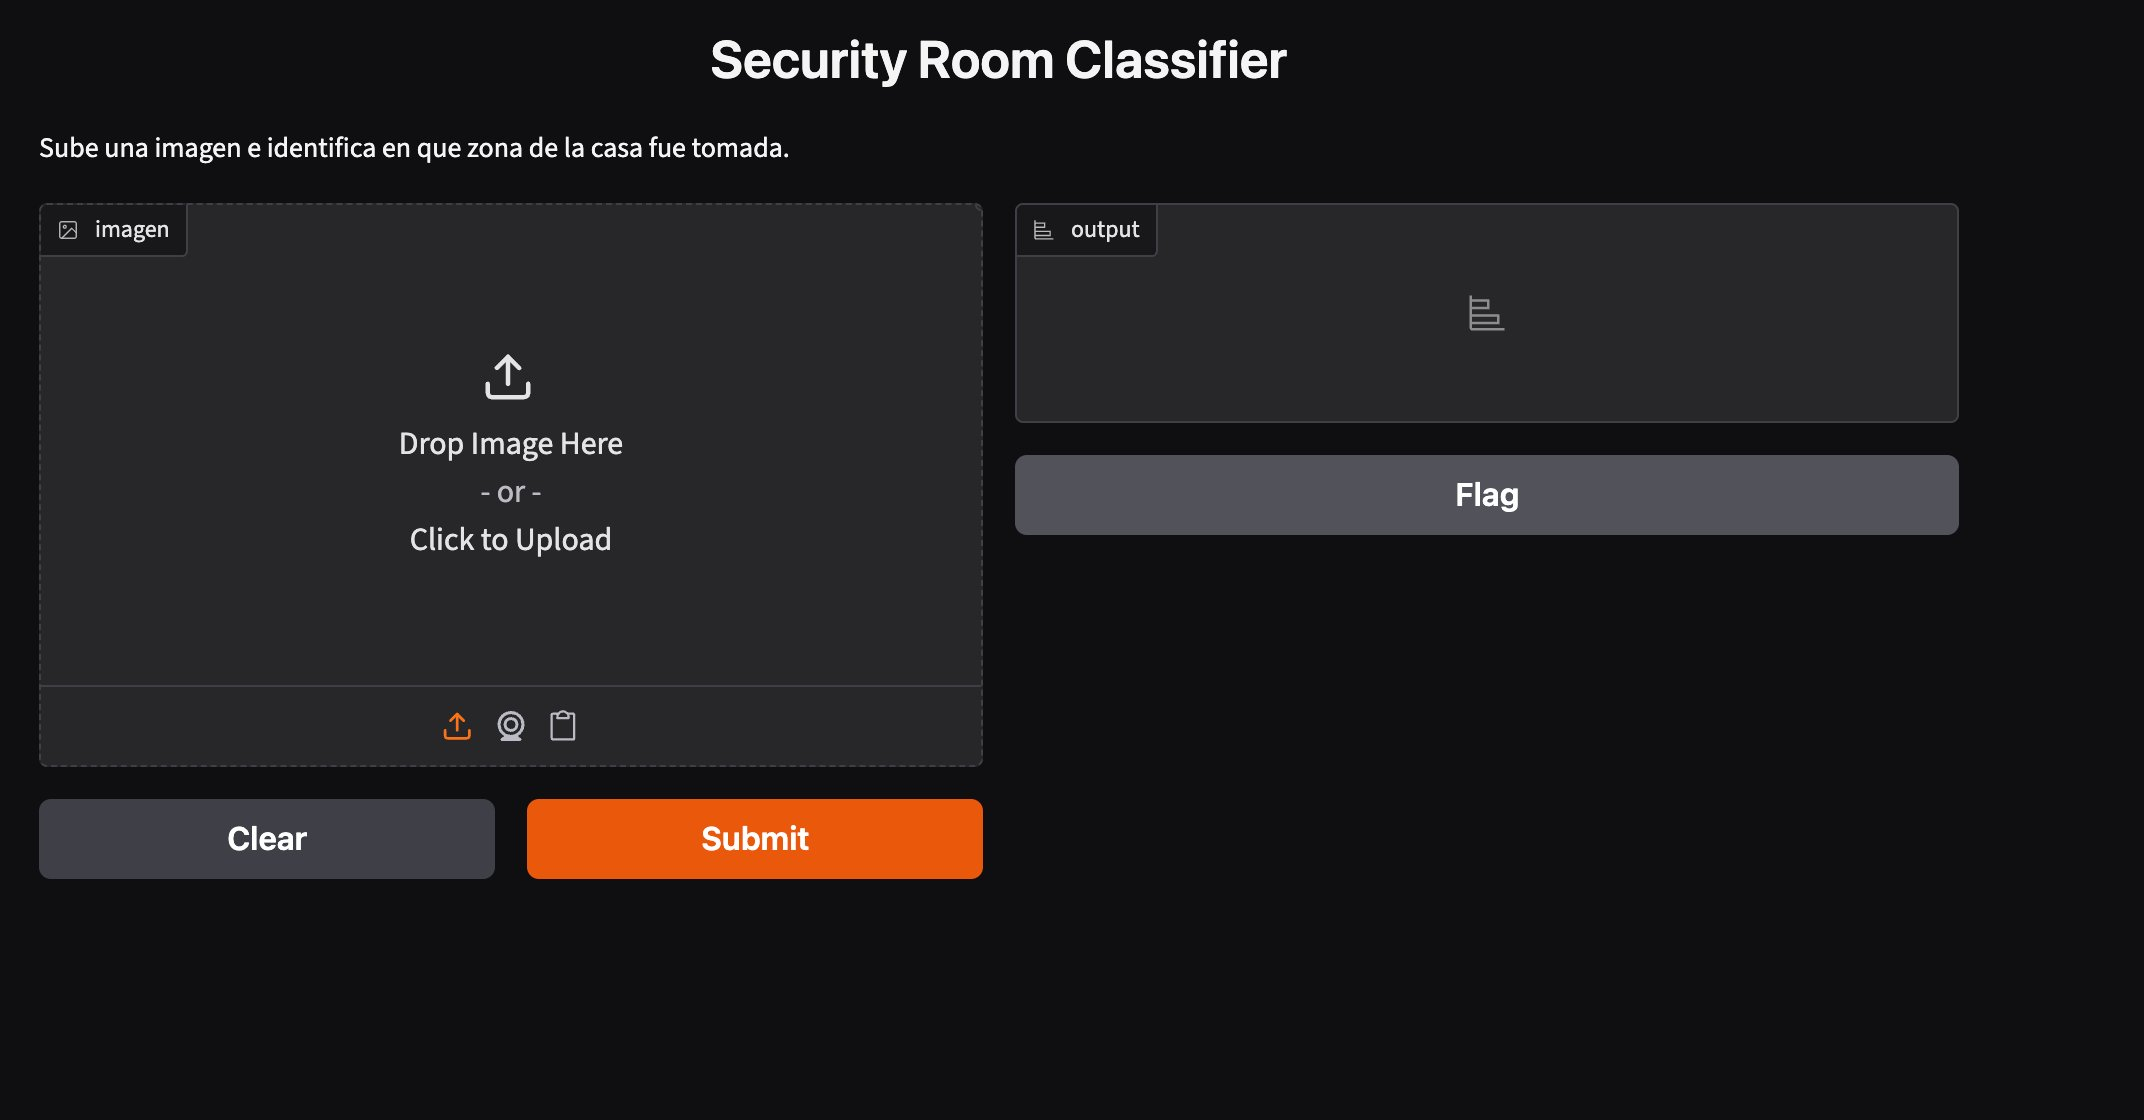

*App Gradio corriendo en https://cv-proyectofinal-production.up.railway.app*


---

## Conclusiones

- **Embeddings = misma matemática en dominios distintos:** ArcFace y los modelos de lenguaje usan el mismo mecanismo de comparación vectorial.
- **YOLO tiene versiones especializadas:** el modelo de caras supera al genérico en detección facial.
- **MixUp + LabelSmoothing: +3.6% accuracy** en dataset limitado y desbalanceado.
- **Los errores del modelo son informativos:** fallos en clases ambiguas = cuello de botella en el dataset, no en la arquitectura.
- **El margen de decisión de la whitelist es robusto:** 0.94 (autorizado) vs 0.045 (intruso) — separación clara que valida el umbral de 0.5.
